In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import ElasticNet, LinearRegression, Lasso
from sklearn.metrics import root_mean_squared_error
import xgboost as xgb
from src.utils.data_processing import load_data_base,format_database,format_features, add_features
from src.utils.nlp_processing import text_clean,add_nlp_columns

In [37]:
dossier="/home/tiphainell/Documents/5.Direct Assurance/actuarial-loss-estimation"

In [38]:
database=load_data_base(dossier)
#format database
database=format_database(database)


In [39]:
database.describe()

,Age,DependentChildren,DependentsOther,WeeklyWages,HoursWorkedPerWeek,DaysWorkedPerWeek,InitialIncurredCalimsCost,UltimateIncurredClaimCost,DateTimeOfAccident_year,DateTimeOfAccident_month,DateTimeOfAccident_day,DateTimeOfAccident_hour,DateTimeOfAccident_week,reporting_delay
count,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,9.000000e+04,5.400000e+04,90000.000000,90000.000000,90000.000000,90000.000000,90000.0,90000.000000
mean,33.848044,0.119511,0.009811,416.369865,37.744587,4.908422,7.776410e+03,1.100337e+04,1996.500000,6.505578,15.617244,11.572056,26.572511,38.105800
std,12.123000,0.519645,0.108952,246.196704,12.325391,0.547494,1.941012e+04,3.339099e+04,5.188156,3.402471,8.725739,3.743689,14.802449,59.796824
min,13.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000e+00,1.218868e+02,1988.000000,1.000000,1.000000,0.000000,1.0,-1.000000
25%,23.000000,0.000000,0.000000,200.000000,38.000000,5.000000,6.610000e+02,9.263384e+02,1992.000000,4.000000,8.000000,9.000000,14.0,13.000000
50%,32.000000,0.000000,0.000000,393.300000,38.000000,5.000000,2.000000e+03,3.371242e+03,1996.500000,7.000000,16.000000,11.000000,27.0,21.000000
75%,43.000000,0.000000,0.000000,500.000000,40.000000,5.000000,9.500000e+03,8.197249e+03,2001.000000,9.000000,23.000000,14.000000,40.0,40.000000
max,81.000000,9.000000,5.000000,7497.000000,700.000000,7.000000,2.000000e+06,4.027136e+06,2005.000000,12.000000,31.000000,23.000000,53.0,1094.000000


In [40]:
database.groupby('role')['Gender'].value_counts(normalize=True)
#il n'y pas de undefined dans le test, sinon les proportions sont respectées entre le train et le test

role   Gender
test   M         0.775167
       F         0.224833
train  M         0.771481
       F         0.228481
       U         0.000037
Name: proportion, dtype: float64

In [41]:
database.groupby('role')['MaritalStatus'].value_counts(normalize=True)

role   MaritalStatus
test   S                0.486716
       M                0.417403
       U                0.095881
train  S                0.484723
       M                0.417187
       U                0.098090
Name: proportion, dtype: float64

In [42]:

database.groupby('role')['PartTimeFullTime'].value_counts(normalize=True)

role   PartTimeFullTime
test   F                   0.912056
       P                   0.087944
train  F                   0.909481
       P                   0.090519
Name: proportion, dtype: float64

In [43]:
database.groupby('role')['DateTimeOfAccident_year'].value_counts(normalize=True)
# Le test et le train sont équilibrés en terme d'années entre 1988 et 2005 
# Il n'y a pas de split temporel, c'est un random split, à reproduire pour le validation, split random

role   DateTimeOfAccident_year
test   1998                       0.056556
       1990                       0.056361
       1991                       0.056306
       1989                       0.056194
       2003                       0.056167
       1994                       0.056083
       1995                       0.056028
       2000                       0.055750
       2005                       0.055639
       1999                       0.055583
       1993                       0.055472
       2002                       0.055250
       1992                       0.054944
       1988                       0.054917
       2001                       0.054778
       1997                       0.054694
       2004                       0.054667
       1996                       0.054611
train  1996                       0.056185
       2004                       0.056148
       1997                       0.056130
       2001                       0.056074
       1988            

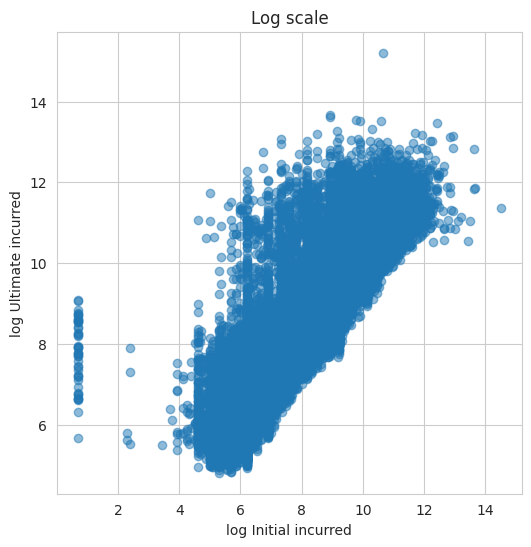

In [44]:
plt.figure(figsize=(6,6))

train=database[database['role']=='train']

plt.scatter(
    np.log1p(train["InitialIncurredCalimsCost"]),
    np.log1p(train["UltimateIncurredClaimCost"]),
    alpha=0.5
)

plt.xlabel("log Initial incurred")
plt.ylabel("log Ultimate incurred")
plt.title("Log scale")
plt.show()

In [45]:
train

,ClaimNumber,DateTimeOfAccident,DateReported,Age,Gender,MaritalStatus,DependentChildren,DependentsOther,WeeklyWages,PartTimeFullTime,...,ClaimDescription,InitialIncurredCalimsCost,UltimateIncurredClaimCost,role,DateTimeOfAccident_year,DateTimeOfAccident_month,DateTimeOfAccident_day,DateTimeOfAccident_hour,DateTimeOfAccident_week,reporting_delay
0,WC8285054,2002-04-09 07:00:00+00:00,2002-07-05T00:00:00Z,48,M,M,0,0,500.00,F,...,LIFTING TYRE INJURY TO RIGHT ARM AND WRIST INJURY,1500,4748.203388,train,2002,4,9,7,15,86
1,WC6982224,1999-01-07 11:00:00+00:00,1999-01-20T00:00:00Z,43,F,M,0,0,509.34,F,...,STEPPED AROUND CRATES AND TRUCK TRAY FRACTURE ...,5500,6326.285819,train,1999,1,7,11,1,12
2,WC5481426,1996-03-25 00:00:00+00:00,1996-04-14T00:00:00Z,30,M,U,0,0,709.10,F,...,CUT ON SHARP EDGE CUT LEFT THUMB,1700,2293.949087,train,1996,3,25,0,13,20
3,WC9775968,2005-06-22 13:00:00+00:00,2005-07-22T00:00:00Z,41,M,S,0,0,555.46,F,...,DIGGING LOWER BACK LOWER BACK STRAIN,15000,17786.487170,train,2005,6,22,13,25,29
4,WC2634037,1990-08-29 08:00:00+00:00,1990-09-27T00:00:00Z,36,M,M,0,0,377.10,F,...,REACHING ABOVE SHOULDER LEVEL ACUTE MUSCLE STR...,2800,4014.002925,train,1990,8,29,8,35,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53995,WC9370727,2004-08-21 18:00:00+00:00,2004-09-08T00:00:00Z,32,F,S,0,0,500.00,F,...,STRUCK KNIFE LACERATED LEFT MIDDLE FINGER LEFT...,1000,480.493308,train,2004,8,21,18,34,17
53996,WC8396269,2002-04-28 09:00:00+00:00,2002-09-03T00:00:00Z,20,F,S,0,0,500.00,F,...,LEFT HAND LACERATION LEFT SIDE BACK AND LEFT LEG,1000,755.735319,train,2002,4,28,9,17,127
53997,WC3609528,1992-02-28 09:00:00+00:00,1992-03-18T00:00:00Z,19,M,S,0,0,283.00,F,...,METAL SLIPPED ACROSS METAL CUT FINGER,210,418.178461,train,1992,2,28,9,9,18
53998,WC5038565,1995-01-10 07:00:00+00:00,1995-01-31T00:00:00Z,24,M,S,0,0,200.00,F,...,BURN WHILST USING SPANNER LACERATION RIGHT MID...,7500,2695.225700,train,1995,1,10,7,2,20


In [46]:

#database=add_nlp_columns(database)

In [47]:
#Model

database=format_features(database)
database=add_features(database)
features_x=database.columns.tolist()
cols_to_remove = [
    "ClaimNumber",
    "DateTimeOfAccident",
    "UltimateIncurredClaimCost",
    "DateReported",
    "ClaimDescription",
    "ClaimDescriptionClean",
    "role",
    "claim_development_ratio"
]

features_x = [
    col for col in features_x
    if col not in cols_to_remove
]

features_y=["UltimateIncurredClaimCost"]
#features_y=["claim_development_ratio"]
train=database[database['role']=='train']
X_train, X_val, y_train, y_val=train_test_split(train[features_x], train[features_y], test_size=0.2,random_state=42)

In [48]:
y_train

,UltimateIncurredClaimCost
5688,283.190726
40513,34714.685240
17163,3377.554269
39180,6218.812059
7905,27947.355280
...,...
11284,5558.537363
44732,351.801179
38158,5605.758168
860,1320.192511


In [49]:
weights = np.where(
    y_train > y_train.quantile(0.95),
    2,
    1
)
model=xgb.XGBRegressor(n_estimators=100,max_depth=6)
trained_model=model.fit(X_train, np.log1p(y_train), sample_weight=weights)
y_predict=trained_model.predict(X_val)
y_pred = np.expm1(y_predict)
root_mean_squared_error(y_val,y_pred )

25812.36328125

In [50]:
y_val

,UltimateIncurredClaimCost
30246,4186.838233
34164,1805.475703
40692,2679.339455
28724,525.627329
28097,3859.038178
...,...
37925,3887.220555
10036,516.497030
52443,5190.162504
25449,74501.663270


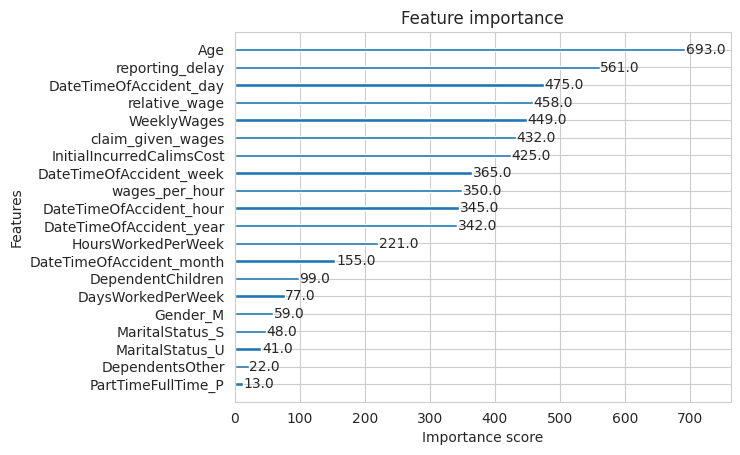

In [51]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(trained_model, max_num_features=20)
plt.show()

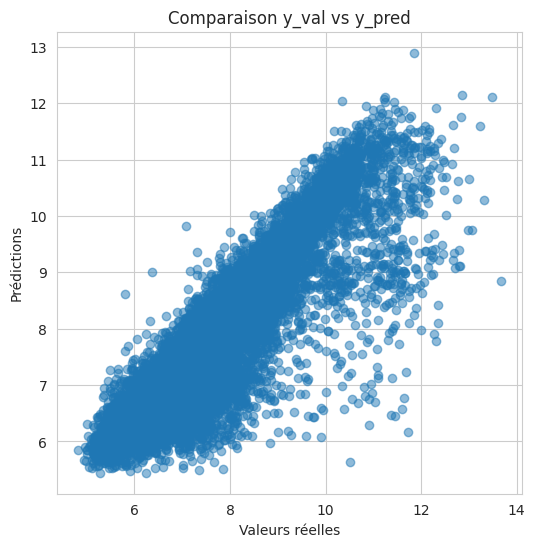

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(np.log1p(y_val), y_predict, alpha=0.5)

#plt.plot([y_val.min(), y_val.max()],
#         [y_val.min(), y_val.max()],
#         color="red")

plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Comparaison y_val vs y_pred")
plt.show()

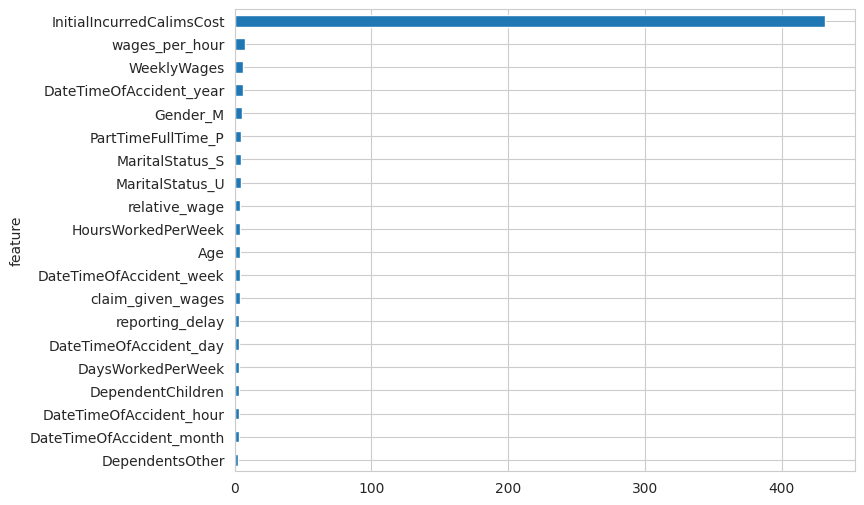

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

importance = trained_model.get_booster().get_score(importance_type="gain")

df_importance = pd.DataFrame({
    "feature": list(importance.keys()),
    "importance": list(importance.values())
})

df_importance = df_importance.sort_values(by="importance", ascending=False).head(20)

df_importance.plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False,
    figsize=(8,6)
)

plt.gca().invert_yaxis()
plt.show()

In [54]:
test=database[database['role']=='test']
X_test=test[features_x]
y_test=test[features_y]
y_predict=trained_model.predict(X_test)



In [55]:
import shap
import matplotlib.pyplot as plt
explainer = shap.TreeExplainer(trained_model)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train)

ValueError: could not convert string to float: '[8.225559E0]'

In [56]:
trained_model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [57]:
X_train.select_dtypes(include=["category"]).columns

Index([], dtype='object')

In [58]:
test_preds = np.mean([
    np.expm1(model.predict(X_test))
    for model in models
], axis=0)

NameError: name 'models' is not defined

In [59]:
test_preds

NameError: name 'test_preds' is not defined

In [62]:
#results=pd.DataFrame({
#    "ClaimNumber":test["ClaimNumber"],
#    "UltimateIncurredClaimCost":test_preds})

results=pd.DataFrame({
    "ClaimNumber":test["ClaimNumber"],
    "UltimateIncurredClaimCost":test["InitialIncurredCalimsCost"]})

In [63]:
results

,ClaimNumber,UltimateIncurredClaimCost
0,WC8145235,5300
1,WC2005111,2000
2,WC6899143,20000
3,WC5502023,350
4,WC4785156,3000
...,...,...
35995,WC9666858,9500
35996,WC4800526,400
35997,WC3360567,7600
35998,WC7491778,10000


In [64]:
results.to_csv("resultat_avec_baseline.csv", index=False)